# 205 — HP thomas_dill deep dive: why does it beat Lehninger where it matters?

hp_thomas_dill never ran through the genome-wide pipeline sweep (dash/underscore indexDatabase bug,
see [[pipeline_thomas_dill_empty_index_bug]]), so it was absent from notebook 200's alphabet×ksize
ranking. It was generated directly here and in notebooks 200/203/211 against one-off populated
indices. Two findings so far:

- **Notebook 211 (MHC):** hp_thomas_dill k=26 gets class I AUC-ROC=0.817 and class II
  AUC-ROC=0.997, beating plain HP Lehninger's best (class I 0.777 at k=28) and beating
  protein/dayhoff on class I (0.434 and 0.632).
- **Notebook 200 (SCOPe, prior work):** thomas_dill k=26 was the designated best HP alphabet
  against FoldSeek on fold recognition, a harder and more remote-homology benchmark than the
  human-mouse ortholog task.

This notebook asks why, using the one verifiable difference between the two alphabets. Kmerseek's
`hp_alphabets.rs` defines:

| | H (hydrophobic) | P (polar) |
|---|---|---|
| **Lehninger** | A F G I L M P V W Y | C D E H K N Q R S T |
| **Thomas-Dill** | A C F I L M V W Y | D E G H K N P Q R S T |

Three residues move: **G**lycine and **P**roline go hydrophobic→polar, **C**ysteine goes
polar→hydrophobic. Everything else in the 20-letter alphabet is classified identically. Section 2
checks whether this reclassification plausibly explains the advantage, by comparing G/P/C
composition between the domains where thomas_dill's edge shows up and the domains where it does
not. Composition correlation is not proof of mechanism.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path(".").resolve()))
import ortholog_analysis_utils as ou

DATA_DIR = ou.DATA_DIR
HUMAN_FA = Path(
    "/Users/olga/data/gencode/human/v49/gencode.v49.pc_translations.canonical.fa"
)

# Verified directly from kmerseek/src/rust/hp_alphabets.rs
LEHNINGER_H = set("AFGILMPVWY")
LEHNINGER_P = set("CDEHKNQRST")
THOMAS_DILL_H = set("ACFILMVWY")
THOMAS_DILL_P = set("DEGHKNPQRST")
RECLASSIFIED = {"G": "H\u2192P", "P": "H\u2192P", "C": "P\u2192H"}
assert LEHNINGER_H - THOMAS_DILL_H == {"G", "P"}
assert THOMAS_DILL_H - LEHNINGER_H == {"C"}
print("Reclassified residues (Lehninger -> Thomas-Dill):", RECLASSIFIED)

print("query present:", HUMAN_FA.exists())

Reclassified residues (Lehninger -> Thomas-Dill): {'G': 'H→P', 'P': 'H→P', 'C': 'P→H'}
query present: True


## 1. Genome-wide standing: thomas_dill vs the field

Reuses notebook 200's cached sweep (`200_alphabet_ksize_matched_scope_comparison.csv`) plus the
thomas_dill k=25/26 combos computed there and in notebook 203, all scored the same way: RBH F1 vs
MGI, with OrthoFinder re-scored on the matched gene universe (notebook 200, section 2).

shape: (10, 4)
┌─────────────────────────┬─────────────┬────────────────────────┬────────────────────┐
│ combo                   ┆ kmerseek_F1 ┆ orthofinder_F1_matched ┆ gap_to_orthofinder │
│ ---                     ┆ ---         ┆ ---                    ┆ ---                │
│ str                     ┆ f64         ┆ f64                    ┆ f64                │
╞═════════════════════════╪═════════════╪════════════════════════╪════════════════════╡
│ protein_k15             ┆ 0.894538    ┆ 0.89685                ┆ 0.002312           │
│ dayhoff_k20             ┆ 0.874237    ┆ 0.886806               ┆ 0.012569           │
│ hp_kyte_doolittle_k16   ┆ 0.864865    ┆ 0.974359               ┆ 0.109494           │
│ hp_pbotc_1st_ed_k30     ┆ 0.82577     ┆ 0.869099               ┆ 0.043328           │
│ hp_lehninger_k30        ┆ 0.816267    ┆ 0.866998               ┆ 0.050731           │
│ hp_lehninger_plus_c_k30 ┆ 0.816234    ┆ 0.865871               ┆ 0.049636           │
│ hp_k30         

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_70441/55351065.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(compare_df["combo"].to_list(), rotation=30, ha="right", fontsize=9)


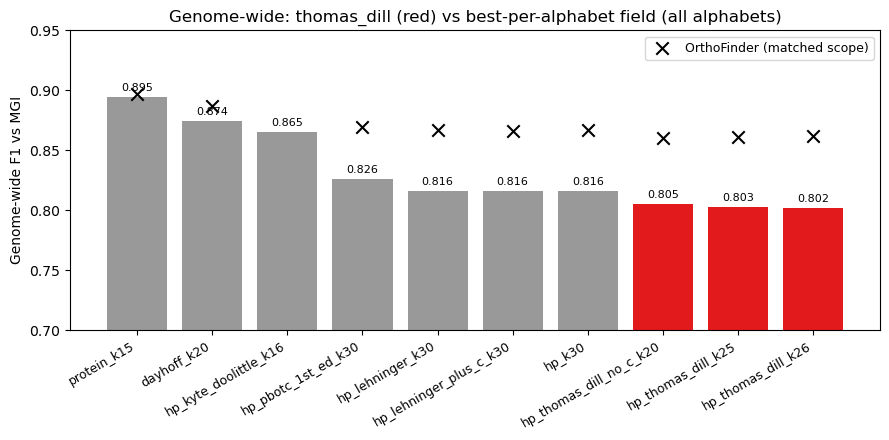

In [2]:
# 2026-08-11: switched from the narrow protein/dayhoff/hp-only sweep + a separate curated
# thomas_dill CSV to the pipeline's unified 200_rbh_f1_all_combos.csv (see notebook 200 §1 and
# nb200_section2b_pipeline_move memory note) -- "the field" now means every alphabet notebook
# 200 tracks, including thomas_dill's closest competitors, the other 5 HP variants
# (lehninger, lehninger_plus_c, kyte_doolittle, pbotc_1st_ed, thomas_dill_no_c), which the old
# narrow sweep excluded from the comparison entirely.
rbh_f1_all = pl.read_csv(DATA_DIR / "200_rbh_f1_all_combos.csv")

# Best-per-alphabet comparison set: thomas_dill (both k) vs the single best combo from every
# OTHER alphabet in notebook 200's ranking. thomas_dill itself is excluded from this grouping --
# it gets its own two dedicated rows (k=25, k=26) below instead of being folded into a single
# best-k bar like everything else.
best_per_alphabet = (
    rbh_f1_all.filter(pl.col("encoding") != "hp_thomas_dill")
    .sort("kmerseek_F1", descending=True)
    .group_by("encoding", maintain_order=False)
    .head(1)
)
thomas_dill_df = rbh_f1_all.filter(
    (pl.col("encoding") == "hp_thomas_dill") & (pl.col("ksize").is_in([25, 26]))
)
compare_df = pl.concat(
    [best_per_alphabet, thomas_dill_df], how="diagonal_relaxed"
).sort("kmerseek_F1", descending=True)
compare_df = compare_df.with_columns(
    (pl.col("encoding") + "_k" + pl.col("ksize").cast(pl.Utf8)).alias("combo")
)
print(
    compare_df.select(
        ["combo", "kmerseek_F1", "orthofinder_F1_matched", "gap_to_orthofinder"]
    )
)

fig, ax = plt.subplots(figsize=(max(8, 0.9 * compare_df.height), 4.5))
colors = [
    "#e31a1c" if "thomas_dill" in c else "#999999"
    for c in compare_df["combo"].to_list()
]
bars = ax.bar(
    compare_df["combo"].to_list(), compare_df["kmerseek_F1"].to_list(), color=colors
)
ax.scatter(
    compare_df["combo"].to_list(),
    compare_df["orthofinder_F1_matched"].to_list(),
    marker="x",
    s=80,
    color="black",
    zorder=5,
    label="OrthoFinder (matched scope)",
)
for bar, v in zip(bars, compare_df["kmerseek_F1"].to_list()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.005,
        f"{v:.3f}",
        ha="center",
        fontsize=8,
    )
ax.set_xticklabels(compare_df["combo"].to_list(), rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Genome-wide F1 vs MGI")
ax.set_ylim(0.7, 0.95)
ax.set_title(
    "Genome-wide: thomas_dill (red) vs best-per-alphabet field (all alphabets)"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(
    DATA_DIR / "205_genomewide_thomas_dill_vs_field.png", dpi=150, bbox_inches="tight"
)
plt.show()

## 2. The mechanistic difference: G/P/C composition where thomas_dill's edge shows up

Notebook 211 found thomas_dill's edge over Lehninger concentrated in **MHC class I**, with the
shared k-mers there riding the conserved **Ig-like α3 domain** rather than the peptide-binding ARD.
If the G→P, P→P, C→H reclassification does mechanistic work, the domains where thomas_dill's edge
appears should differ in G/P/C content from the domains where it does not. Checked on the HLA-A
sequence (UniProt P04439 domain boundaries, shared as `ou.DOMAINS_CLASS_I`; see notebook 212).

ARD (peptide-binding, 182 aa): G=8.2% P=2.7% C=1.1%  G+P+C=12.1%
Ig domain (conserved α3, 92 aa): G=6.5% P=8.7% C=2.2%  G+P+C=17.4%


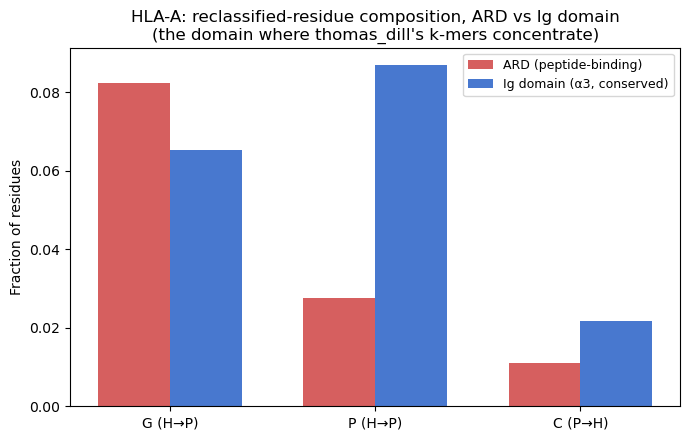


Caveat: this is a composition correlation on ONE molecule (HLA-A), not a causal test --
it shows the reclassified residues are NOT evenly distributed between the two domains,
consistent with the reclassification mattering, but does not prove it drives the effect.


In [3]:
def read_fasta_dict(path: Path) -> dict[str, str]:
    seqs, header, chunks = {}, None, []
    for line in path.read_text().splitlines():
        if line.startswith(">"):
            if header is not None:
                seqs[header] = "".join(chunks)
            header = line[1:]
            chunks = []
        else:
            chunks.append(line)
    if header is not None:
        seqs[header] = "".join(chunks)
    return seqs


all_seqs = read_fasta_dict(HUMAN_FA)
hla_a_header = next(h for h in all_seqs if "|HLA-A|" in h)
hla_a_seq = all_seqs[hla_a_header].replace("*", "")

# UniProt P04439 domain boundaries (protein numbering incl. signal peptide), now shared as ou.DOMAINS_CLASS_I
ARD = hla_a_seq[
    24:206
]  # alpha1 (25-114) + alpha2 (115-206), the peptide-binding domain
IG = hla_a_seq[206:298]  # alpha3 (207-298), the conserved Ig-like domain


def composition(region: str) -> dict:
    n = len(region)
    g, p, c = region.count("G"), region.count("P"), region.count("C")
    return dict(
        n=n,
        G=g,
        P=p,
        C=c,
        G_frac=g / n,
        P_frac=p / n,
        C_frac=c / n,
        GPC_frac=(g + p + c) / n,
    )


comp_ard = composition(ARD)
comp_ig = composition(IG)
print(
    f"ARD (peptide-binding, {comp_ard['n']} aa): G={comp_ard['G_frac']:.1%} P={comp_ard['P_frac']:.1%} "
    f"C={comp_ard['C_frac']:.1%}  G+P+C={comp_ard['GPC_frac']:.1%}"
)
print(
    f"Ig domain (conserved \u03b13, {comp_ig['n']} aa): G={comp_ig['G_frac']:.1%} P={comp_ig['P_frac']:.1%} "
    f"C={comp_ig['C_frac']:.1%}  G+P+C={comp_ig['GPC_frac']:.1%}"
)

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(3)
w = 0.35
ax.bar(
    x - w / 2,
    [comp_ard["G_frac"], comp_ard["P_frac"], comp_ard["C_frac"]],
    w,
    label="ARD (peptide-binding)",
    color="#D65F5F",
)
ax.bar(
    x + w / 2,
    [comp_ig["G_frac"], comp_ig["P_frac"], comp_ig["C_frac"]],
    w,
    label="Ig domain (\u03b13, conserved)",
    color="#4878CF",
)
ax.set_xticks(x)
ax.set_xticklabels(["G (H\u2192P)", "P (H\u2192P)", "C (P\u2192H)"])
ax.set_ylabel("Fraction of residues")
ax.set_title(
    "HLA-A: reclassified-residue composition, ARD vs Ig domain\n(the domain where thomas_dill's k-mers concentrate)"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(
    DATA_DIR / "205_gpc_composition_ard_vs_ig.png", dpi=150, bbox_inches="tight"
)
plt.show()

print(
    "\nCaveat: this is a composition correlation on ONE molecule (HLA-A), not a causal test --"
)
print(
    "it shows the reclassified residues are NOT evenly distributed between the two domains,"
)
print(
    "consistent with the reclassification mattering, but does not prove it drives the effect."
)

## 3. MHC recap: thomas_dill k=25 vs k=26 vs the field (from notebook 211)

Re-derives notebook 211's per-combo recovery/AUC numbers, filtered to thomas_dill at both k-sizes
plus the best combo from each of the other three alphabets.

hp_thomas_dill_k25  class I AUC-ROC=0.767  class II AUC-ROC=0.998
hp_thomas_dill_k26  class I AUC-ROC=0.817  class II AUC-ROC=0.997
hp_lehninger_k28    class I AUC-ROC=0.777  class II AUC-ROC=0.994
protein_k15         class I AUC-ROC=0.226  class II AUC-ROC=0.875
dayhoff_k20         class I AUC-ROC=0.474  class II AUC-ROC=1.000


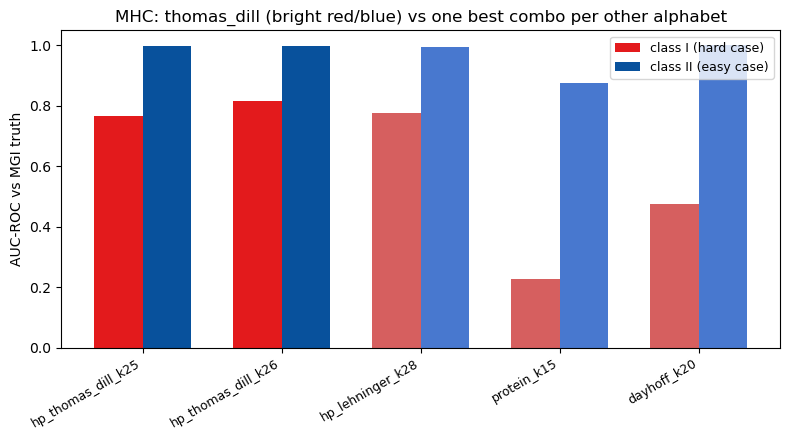

In [4]:
import subprocess
from sklearn.metrics import roc_auc_score, average_precision_score

RES = DATA_DIR
MHC_CLASSES = {
    "HLA-A": "I classical",
    "HLA-B": "I classical",
    "HLA-C": "I classical",
    "HLA-E": "I non-classical",
    "HLA-F": "I non-classical",
    "HLA-G": "I non-classical",
    "MICA": "I related (MIC)",
    "MICB": "I related (MIC)",
    "HLA-DRA": "II alpha",
    "HLA-DQA1": "II alpha",
    "HLA-DQA2": "II alpha",
    "HLA-DPA1": "II alpha",
    "HLA-DMA": "II alpha",
    "HLA-DOA": "II alpha",
    "HLA-DRB1": "II beta",
    "HLA-DRB5": "II beta",
    "HLA-DQB1": "II beta",
    "HLA-DQB2": "II beta",
    "HLA-DPB1": "II beta",
    "HLA-DMB": "II beta",
    "HLA-DOB": "II beta",
    "B2M": "light chain",
    "TAP1": "processing (ctrl)",
    "TAP2": "processing (ctrl)",
    "TAPBP": "processing (ctrl)",
}

# Read the MHC search CSVs notebook 210 already generated/cached (same combo_label convention)
MHC_COMBOS = [
    ("hp_thomas_dill", 25),
    ("hp_thomas_dill", 26),
    ("hp_lehninger", 28),
    ("protein", 15),
    ("dayhoff", 20),
]
COMBO_FILE_LABELS = {
    ("hp_thomas_dill", 25): "hp_thomas_dill_k25",
    ("hp_thomas_dill", 26): "hp_thomas_dill_k26",
    ("hp_lehninger", 28): "hp_lehninger_k28",
    ("protein", 15): "protein_k15",
    ("dayhoff", 20): "dayhoff_k20",
}

mgi_pairs, mgi_set = ou.load_mgi_orthologs()

mhc_rows = []
for combo, file_label in COMBO_FILE_LABELS.items():
    csv_path = RES / f"210_human_mhc_vs_mouse.{file_label}.csv"
    if not csv_path.exists():
        print(f"{file_label}: MISSING ({csv_path.name}) -- skipped")
        continue
    df = pl.read_csv(csv_path).with_columns(
        [
            pl.col("query_name")
            .str.split("|")
            .list.get(6)
            .str.to_uppercase()
            .alias("human_gene"),
            pl.col("target_name")
            .str.split("|")
            .list.get(6)
            .str.to_uppercase()
            .alias("mouse_gene"),
        ]
    )
    pair = (
        df.group_by(["human_gene", "mouse_gene"])
        .agg(pl.col("containment").max())
        .with_columns(
            [
                pl.col("human_gene")
                .replace_strict(MHC_CLASSES, default="other")
                .alias("mhc_class"),
                pl.struct(["human_gene", "mouse_gene"])
                .map_elements(
                    lambda s: (s["human_gene"], s["mouse_gene"]) in mgi_set,
                    return_dtype=pl.Boolean,
                )
                .alias("is_ortholog"),
            ]
        )
    )
    ci = pair.filter(
        pl.col("mhc_class").str.starts_with("I ")
        & ~pl.col("mhc_class").str.contains("MIC")
    )
    cii = pair.filter(pl.col("mhc_class").str.starts_with("II"))
    y_ci, s_ci = ci["is_ortholog"].to_numpy().astype(int), ci["containment"].to_numpy()
    y_cii, s_cii = (
        cii["is_ortholog"].to_numpy().astype(int),
        cii["containment"].to_numpy(),
    )
    auc_ci = roc_auc_score(y_ci, s_ci) if 0 < y_ci.sum() < len(y_ci) else float("nan")
    auc_cii = (
        roc_auc_score(y_cii, s_cii) if 0 < y_cii.sum() < len(y_cii) else float("nan")
    )
    mhc_rows.append(dict(combo=file_label, class_I_auc=auc_ci, class_II_auc=auc_cii))
    print(
        f"{file_label:18s}  class I AUC-ROC={auc_ci:.3f}  class II AUC-ROC={auc_cii:.3f}"
    )

mhc_df = pl.DataFrame(mhc_rows)
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(mhc_df))
w = 0.35
colors_ci = [
    "#e31a1c" if "thomas_dill" in c else "#D65F5F" for c in mhc_df["combo"].to_list()
]
colors_cii = [
    "#08519c" if "thomas_dill" in c else "#4878CF" for c in mhc_df["combo"].to_list()
]
ax.bar(
    x - w / 2,
    mhc_df["class_I_auc"].to_list(),
    w,
    label="class I (hard case)",
    color=colors_ci,
)
ax.bar(
    x + w / 2,
    mhc_df["class_II_auc"].to_list(),
    w,
    label="class II (easy case)",
    color=colors_cii,
)
ax.set_xticks(x)
ax.set_xticklabels(mhc_df["combo"].to_list(), rotation=30, ha="right", fontsize=9)
ax.set_ylabel("AUC-ROC vs MGI truth")
ax.set_ylim(0, 1.05)
ax.set_title("MHC: thomas_dill (bright red/blue) vs one best combo per other alphabet")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / "205_mhc_thomas_dill_vs_field.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Disorder-quartile recap (from notebook 203)

Does thomas_dill's edge concentrate in a particular disorder quartile genome-wide, the way its MHC
class I edge concentrates in the conserved Ig domain rather than the polymorphic ARD?

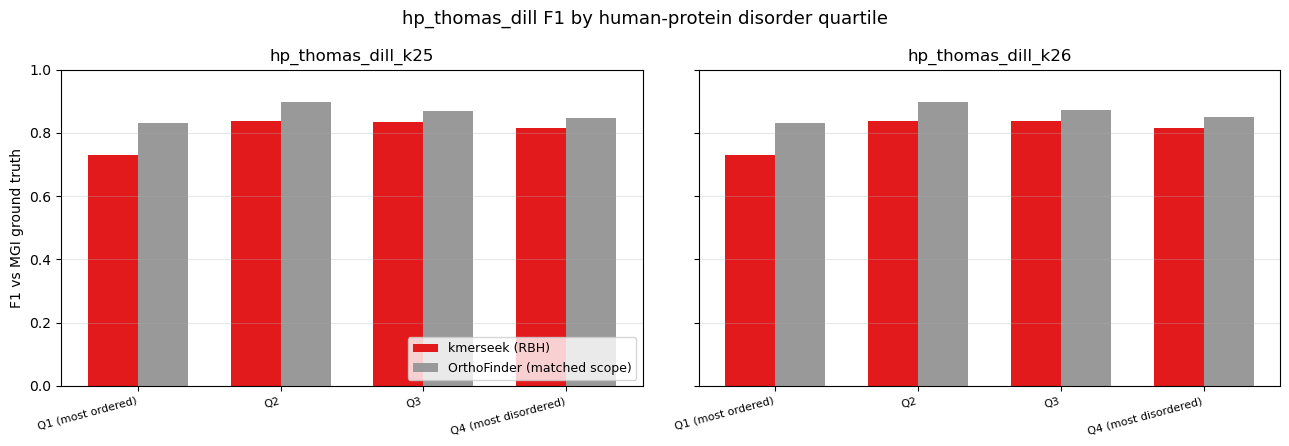

combo,disorder_bin,kmerseek_F1,orthofinder_F1
str,str,f64,f64
"""hp_thomas_dill_k25""","""Q1 (most ordered)""",0.729227,0.83176
"""hp_thomas_dill_k25""","""Q2""",0.836719,0.897777
"""hp_thomas_dill_k25""","""Q3""",0.835808,0.869206
"""hp_thomas_dill_k25""","""Q4 (most disordered)""",0.816241,0.848248
"""hp_thomas_dill_k26""","""Q1 (most ordered)""",0.7286,0.831746
"""hp_thomas_dill_k26""","""Q2""",0.836069,0.897765
"""hp_thomas_dill_k26""","""Q3""",0.837441,0.871859
"""hp_thomas_dill_k26""","""Q4 (most disordered)""",0.815003,0.84878


In [5]:
rbh_25, scope_25 = ou.rbh_pairs_and_scope("hp_thomas_dill", 25)
rbh_26, scope_26 = ou.rbh_pairs_and_scope("hp_thomas_dill", 26)
of_set_all = ou.load_orthofinder_predictions()

dis_df = pl.read_csv(DATA_DIR / "203_human_gene_disorder_metapredict.csv")
disorder_map = dict(
    zip(dis_df["human_gene"].to_list(), dis_df["mean_disorder"].to_list())
)
QUARTILE_LABELS = ["Q1 (most ordered)", "Q2", "Q3", "Q4 (most disordered)"]

quart_rows = []
for label_name, rbh_set, scope in [
    ("hp_thomas_dill_k25", rbh_25, scope_25),
    ("hp_thomas_dill_k26", rbh_26, scope_26),
]:
    mgi_scope_set = {(h, m) for (h, m) in mgi_set if h in scope}
    of_scope_set = {(h, m) for (h, m) in of_set_all if h in scope}
    scope_with_dis = [g for g in scope if g in disorder_map]
    dis_vals = np.array([disorder_map[g] for g in scope_with_dis])
    q_cuts = np.quantile(dis_vals, [0.25, 0.5, 0.75])
    gene_bin = {}
    for g in scope_with_dis:
        d = disorder_map[g]
        gene_bin[g] = (
            QUARTILE_LABELS[0]
            if d <= q_cuts[0]
            else (
                QUARTILE_LABELS[1]
                if d <= q_cuts[1]
                else QUARTILE_LABELS[2] if d <= q_cuts[2] else QUARTILE_LABELS[3]
            )
        )
    for ql in QUARTILE_LABELS:
        bin_genes = {g for g, b in gene_bin.items() if b == ql}
        truth_b = {(h, m) for (h, m) in mgi_scope_set if h in bin_genes}
        ks_b = {(h, m) for (h, m) in rbh_set if h in bin_genes}
        of_b = {(h, m) for (h, m) in of_scope_set if h in bin_genes}
        ks_p, ks_r, ks_f1, *_ = ou.prf1(ks_b, truth_b)
        of_p, of_r, of_f1, *_ = ou.prf1(of_b, truth_b)
        quart_rows.append(
            dict(
                combo=label_name,
                disorder_bin=ql,
                kmerseek_F1=ks_f1,
                orthofinder_F1=of_f1,
            )
        )

quart_df = pl.DataFrame(quart_rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, combo in zip(axes, ["hp_thomas_dill_k25", "hp_thomas_dill_k26"]):
    sub = quart_df.filter(pl.col("combo") == combo)
    sub = pl.DataFrame({"disorder_bin": QUARTILE_LABELS}).join(
        sub, on="disorder_bin", how="left"
    )
    x = np.arange(len(QUARTILE_LABELS))
    w = 0.35
    ax.bar(x - w / 2, sub["kmerseek_F1"], w, label="kmerseek (RBH)", color="#e31a1c")
    ax.bar(
        x + w / 2,
        sub["orthofinder_F1"],
        w,
        label="OrthoFinder (matched scope)",
        color="#999999",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(QUARTILE_LABELS, rotation=15, ha="right", fontsize=8)
    ax.set_title(combo, fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.grid(True, axis="y", alpha=0.3)
axes[0].set_ylabel("F1 vs MGI ground truth")
axes[0].legend(fontsize=9, loc="lower right")
fig.suptitle("hp_thomas_dill F1 by human-protein disorder quartile", fontsize=13)
plt.tight_layout()
plt.savefig(
    DATA_DIR / "205_thomas_dill_disorder_quartile.png", dpi=150, bbox_inches="tight"
)
plt.show()
quart_df

## 4b. Metric choice: does jaccard's win (notebook 200) hold at both k=25 and k=26?

Notebook 200 found that on hp_thomas_dill k=26, plain **jaccard beats every p-value-based
composite** (AUPRC ≈ 0.96 vs the field's best ≈ 0.92), the opposite of notebook 120's result on
plain hp k=24, where a Bonferroni-corrected-p × containment composite won. The explanation offered
there: thomas_dill's containment saturates near 1.0 for almost every candidate pair, so the Poisson
p-value carries no signal (AUROC collapses to 0.500). Checked here at both thomas_dill k-sizes with
the same `ortholog_analysis_utils` 12-metric scoring.

k=25: 1,951,244 pairs, 19,394 human x 20,752 mouse proteins
k=26: 1,794,135 pairs, 19,461 human x 20,650 mouse proteins


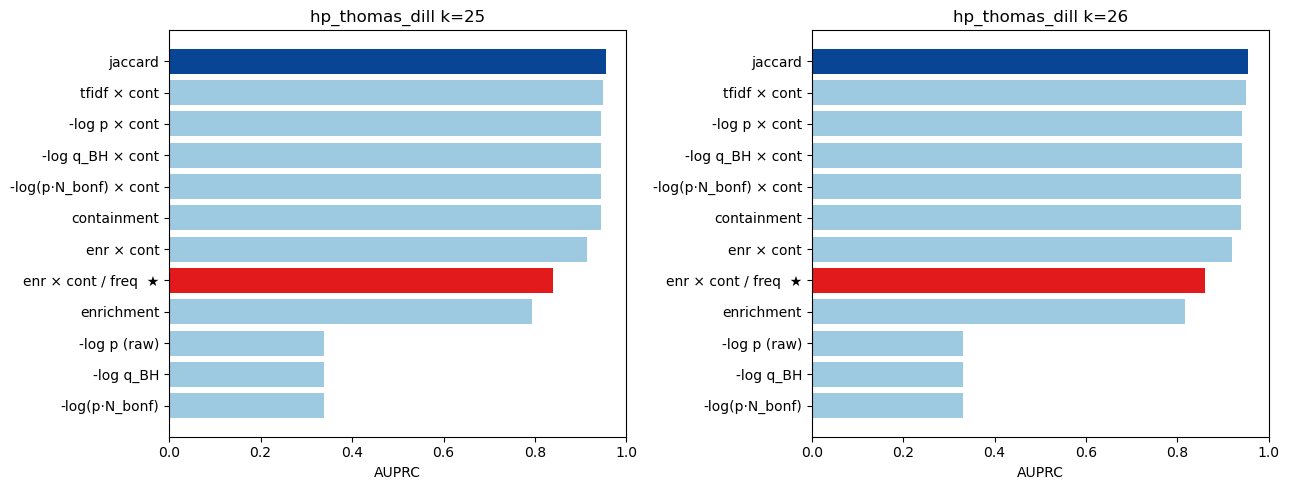


=== hp_thomas_dill k=25 ===
shape: (12, 4)
┌──────┬─────────────────────────┬──────────┬──────────┐
│ rank ┆ metric                  ┆ pr_auc   ┆ roc_auc  │
│ ---  ┆ ---                     ┆ ---      ┆ ---      │
│ i64  ┆ str                     ┆ f64      ┆ f64      │
╞══════╪═════════════════════════╪══════════╪══════════╡
│ 1    ┆ jaccard                 ┆ 0.954418 ┆ 0.979151 │
│ 2    ┆ score_tfidf_cont        ┆ 0.948711 ┆ 0.973559 │
│ 3    ┆ score_neglogp_cont      ┆ 0.944198 ┆ 0.977417 │
│ 4    ┆ score_bh_neglogq_cont   ┆ 0.944198 ┆ 0.977417 │
│ 5    ┆ score_bonf_neglogp_cont ┆ 0.944165 ┆ 0.977337 │
│ …    ┆ …                       ┆ …        ┆ …        │
│ 8    ┆ score_enr_cont_freq     ┆ 0.839738 ┆ 0.93365  │
│ 9    ┆ enrichment              ┆ 0.792863 ┆ 0.895105 │
│ 10   ┆ score_neglogp           ┆ 0.338571 ┆ 0.626404 │
│ 11   ┆ score_bh_neglogq        ┆ 0.338571 ┆ 0.626404 │
│ 12   ┆ score_bonf_neglogp      ┆ 0.338552 ┆ 0.626373 │
└──────┴─────────────────────────┴──────────

In [6]:
td_leaderboards = {}
for k in [25, 26]:
    tsv = DATA_DIR / f"ortholog_evaluation.hp-thomas-dill.k{k}.tsv.zst"
    df_td, n_h, n_m, _ = ou.load_kmerseek_data(
        kmerseek_tsv=tsv, mgi_ortholog_set=mgi_set
    )
    df_td = ou.add_composite_scores(df_td).with_columns(
        pl.col("is_mgi_ortholog").alias("label")
    )
    td_leaderboards[f"hp_thomas_dill k={k}"] = ou.compute_aucs(df_td)
    print(f"k={k}: {df_td.height:,} pairs, {n_h:,} human x {n_m:,} mouse proteins")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, (label, aucs) in zip(axes, td_leaderboards.items()):
    ou.plot_metric_leaderboard(aucs, ax, title=label)
plt.tight_layout()
plt.savefig(
    DATA_DIR / "205_metric_leaderboard_k25_vs_k26.png", dpi=150, bbox_inches="tight"
)
plt.show()

for label, aucs in td_leaderboards.items():
    print(f"\n=== {label} ===")
    print(ou.leaderboard_df(aucs).select(["rank", "metric", "pr_auc", "roc_auc"]))

## 5. Verdict

*Placeholder: filled in after execution against the numbers above.*